<a href="https://colab.research.google.com/github/Dogbware/Mineria_datos/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

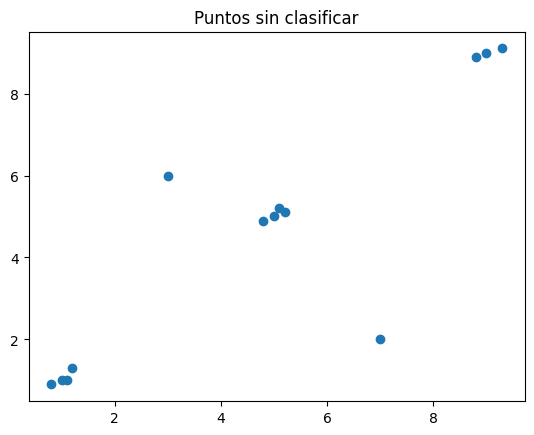

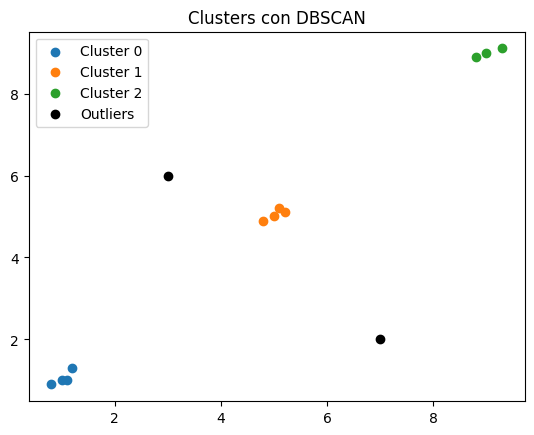

Zonas identificadas: 3


In [2]:
from sklearn.cluster import DBSCAN
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv("zonas_entrega.csv")

# Crear DataFrame con X y Y
datos = df[['X', 'Y']]

# Graficar puntos sin clasificar
plt.scatter(datos['X'], datos['Y'])
plt.title("Puntos sin clasificar")
plt.show()

# Aplicar DBSCAN
modelo = DBSCAN(eps=0.8, min_samples=3)
df['Cluster'] = modelo.fit_predict(datos)

# Graficar clusters
for cluster in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster]

    if cluster == -1:
        plt.scatter(cluster_data['X'], cluster_data['Y'],
                    c='black', label='Outliers')
    else:
        plt.scatter(cluster_data['X'], cluster_data['Y'],
                    label=f'Cluster {cluster}')

plt.legend()
plt.title("Clusters con DBSCAN")
plt.show()

# Número de clusters
num_clusters = len(set(df['Cluster'])) - (1 if -1 in df['Cluster'].values else 0)

print("Zonas identificadas:", num_clusters)

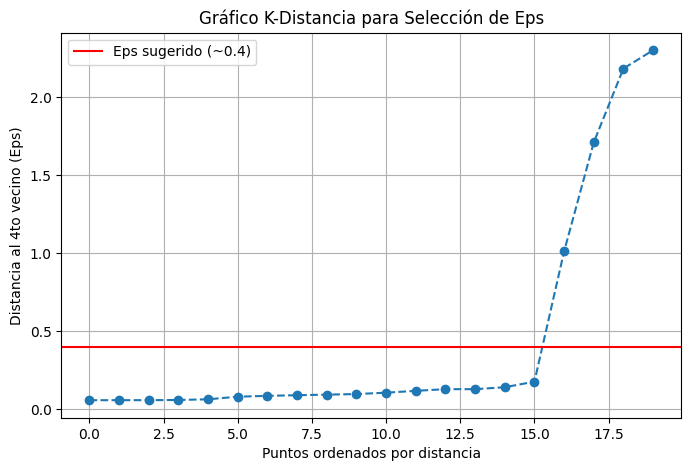

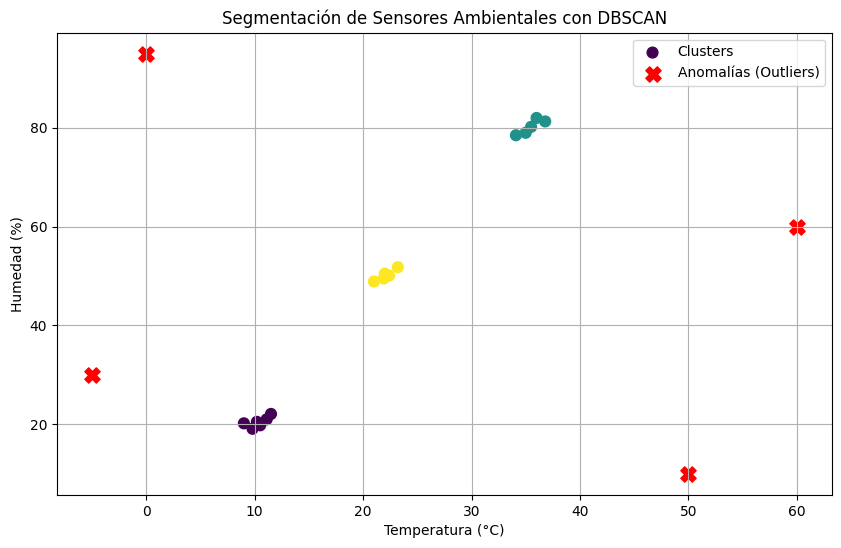

   Sensor  Temperatura_C  Humedad_pct  Tipo_Esperado  Cluster
0      S1           10.2         20.5      Frio/Seco        0
1      S2            9.8         19.1      Frio/Seco        0
2      S3           11.1         21.0      Frio/Seco        0
3      S4           35.5         80.2  Calido/Humedo        1
4      S5           34.1         78.5  Calido/Humedo        1
5      S6           36.8         81.3  Calido/Humedo        1
6      S7           22.4         50.1       Templado        2
7      S8           21.9         49.5       Templado        2
8      S9           23.2         51.8       Templado        2
9     S10           50.0         10.0       ANOMALIA       -1
10    S11            0.0         95.0       ANOMALIA       -1
11    S12           10.5         19.8      Frio/Seco        0
12    S13           35.0         79.0  Calido/Humedo        1
13    S14           22.0         50.5       Templado        2
14    S15           36.0         82.0  Calido/Humedo        1
15    S1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# 1. Cargar y estructurar los datos
df = pd.read_csv('ejercicio_2_sensores_ambientales - ejercicio_2_sensores_ambientales.csv')
X = df[['Temperatura_C', 'Humedad_pct']].values

# 2. Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Calcular las distancias al 4to vecino más cercano
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Ordenar las distancias del tercer vecino
distances = np.sort(distances[:, 3], axis=0)

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(distances, marker='o', linestyle='--')
plt.title('Gráfico K-Distancia para Selección de Eps')
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel('Distancia al 4to vecino (Eps)')
plt.grid(True)
plt.axhline(y=0.4, color='r', linestyle='-', label='Eps sugerido (~0.4)')
plt.legend()
plt.show()
# 4. Aplicar DBSCAN
dbscan = DBSCAN(eps=0.4, min_samples=4)
df['Cluster'] = dbscan.fit_predict(X_scaled)

# 5. Graficar los resultados
plt.figure(figsize=(10, 6))

# Separar los puntos normales de las anomalías
anomalias = df[df['Cluster'] == -1]
normales = df[df['Cluster'] != -1]

# Graficar clusters normales
scatter = plt.scatter(normales['Temperatura_C'], normales['Humedad_pct'],
                      c=normales['Cluster'], cmap='viridis', s=60, label='Clusters')

# Graficar anomalías en rojo y con una 'X'
plt.scatter(anomalias['Temperatura_C'], anomalias['Humedad_pct'],
            color='red', marker='X', s=120, label='Anomalías (Outliers)')

plt.title('Segmentación de Sensores Ambientales con DBSCAN')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Humedad (%)')
plt.legend()
plt.grid(True)
plt.show()

# Mostrar DataFrame con los resultados de los clusters asignados
print(df[['Sensor', 'Temperatura_C', 'Humedad_pct', 'Tipo_Esperado', 'Cluster']])

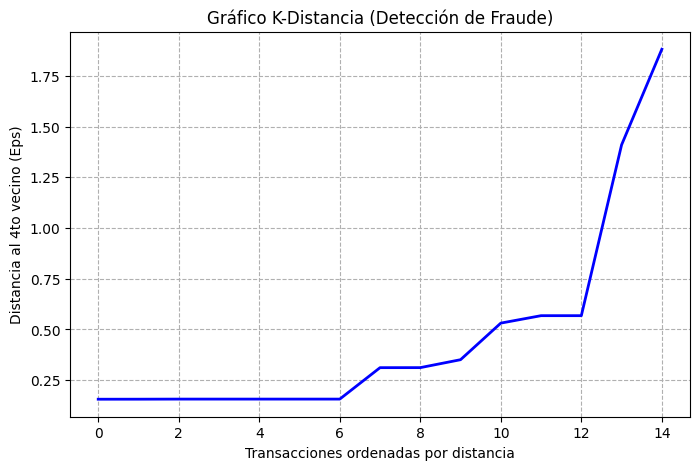

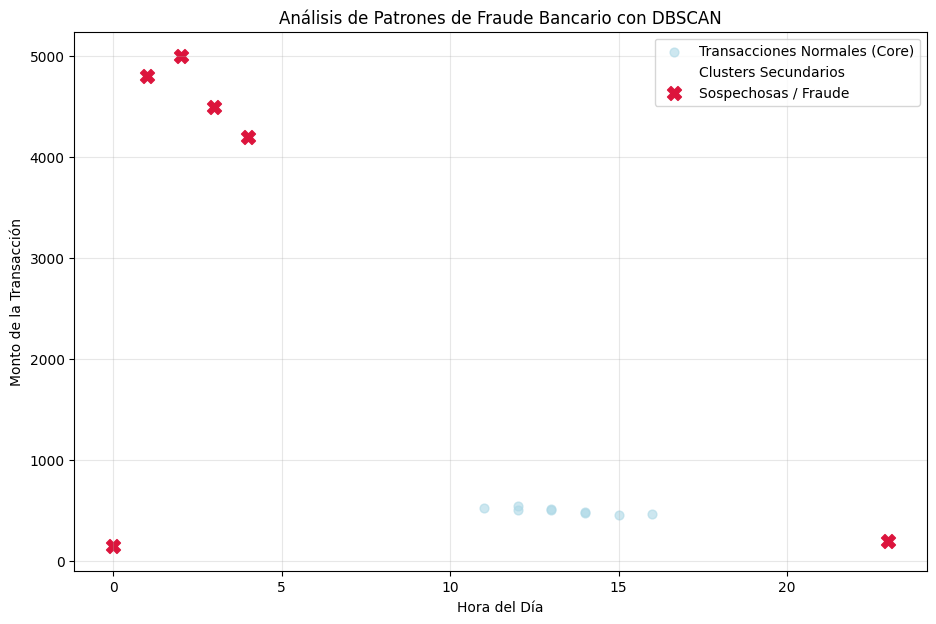

Total de transacciones analizadas: 15
Transacciones marcadas como sospechosas: 6
Porcentaje de sospechas de fraude: 40.00%


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# 1. Cargar y estructurar datos
df = pd.read_csv('fraude_bancario.csv')
X = df[['Monto', 'Hora']].values

# 2. Escalado con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Calcular distancias al 4to vecino
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Ordenar las distancias (columna del 4to vecino, índice 3)
distances = np.sort(distances[:, 3], axis=0)

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(distances, color='blue', lw=2)
plt.title('Gráfico K-Distancia (Detección de Fraude)')
plt.xlabel('Transacciones ordenadas por distancia')
plt.ylabel('Distancia al 4to vecino (Eps)')
plt.grid(True, linestyle='--')
plt.show()
# 4. Configurar y aplicar DBSCAN
dbscan = DBSCAN(eps=0.35, min_samples=4)
df['Cluster'] = dbscan.fit_predict(X_scaled)

# Etiquetar transacciones: -1 es Sospechosa, el resto es Normal
df['Tipo_Transaccion'] = df['Cluster'].apply(lambda x: 'Sospechosa' if x == -1 else 'Normal')
plt.figure(figsize=(11, 7))

# 1. Identificar tipos de clusters
sospechosas = df[df['Cluster'] == -1]
cluster_principal = df[df['Cluster'] == 0]
clusters_secundarios = df[df['Cluster'] > 0]

# 2. Graficar cada categoría
plt.scatter(cluster_principal['Hora'], cluster_principal['Monto'],
            c='lightblue', alpha=0.6, s=40, label='Transacciones Normales (Core)')

plt.scatter(clusters_secundarios['Hora'], clusters_secundarios['Monto'],
            c=clusters_secundarios['Cluster'], cmap='Dark2', s=50, label='Clusters Secundarios')

plt.scatter(sospechosas['Hora'], sospechosas['Monto'],
            color='crimson', marker='X', s=100, label='Sospechosas / Fraude')

plt.title('Análisis de Patrones de Fraude Bancario con DBSCAN')
plt.xlabel('Hora del Día')
plt.ylabel('Monto de la Transacción')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

total_transacciones = len(df)
total_sospechosas = len(sospechosas)
porcentaje_sospechosas = (total_sospechosas / total_transacciones) * 100

print(f"Total de transacciones analizadas: {total_transacciones}")
print(f"Transacciones marcadas como sospechosas: {total_sospechosas}")
print(f"Porcentaje de sospechas de fraude: {porcentaje_sospechosas:.2f}%")